# COVID-19 Data Exploration (EDA)

## Project Overview
This project focuses on exploring global COVID-19 data to understand patterns in case trends, death rates, and vaccination progress across multiple countries.

## Objective
- Analyze COVID-19 case trends over time
- Compare multiple countries
- Identify patterns in deaths and vaccinations
- Generate data-driven insights

## Dataset
The dataset used in this project is sourced from Our World in Data, which provide comprehensive global COVID-19 data including cases, deaths, and vaccination statistics.

In [11]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../Data/Covid19Data_Small.csv")

## Data Understanding

In this section, we explore the structure of the dataset by:
- Viewing sample data
- Understanding data types
- Identifying missing values
- Reviewing basic statistics

This step is crucial to assess data quality before proceeding with analysis.

In [12]:
# Initial exploration
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 61 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   country                                     8980 non-null   object 
 1   date                                        8980 non-null   object 
 2   total_cases                                 8968 non-null   float64
 3   new_cases                                   7958 non-null   float64
 4   new_cases_smoothed                          7940 non-null   float64
 5   total_cases_per_million                     8968 non-null   float64
 6   new_cases_per_million                       7958 non-null   float64
 7   new_cases_smoothed_per_million              7940 non-null   float64
 8   total_deaths                                8968 non-null   float64
 9   new_deaths                                  8964 non-null   float64
 10  new_deaths_s

,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,total_deaths_per_million,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
count,8.968000e+03,7.958000e+03,7.940000e+03,8968.000000,7958.000000,7940.000000,8.968000e+03,8964.000000,8948.000000,8968.000000,...,8.980000e+03,8980.000000,8980.000000,8980.000000,8980.000000,8980.000000,8980.00000,6735.000000,8980.000000,0.0
mean,4.126728e+07,3.200625e+04,3.207889e+04,73433.592593,53.870058,53.992239,3.749990e+05,229.442436,229.964632,847.621561,...,8.677418e+08,203.974402,33.374751,74.701000,25583.191284,2.596738,10.37500,88.913312,2.187500,NaN
std,4.084860e+07,2.226369e+05,2.141431e+05,101638.902868,225.121491,210.800428,3.959656e+05,745.964675,559.917260,1187.069554,...,5.580312e+08,165.517265,4.807252,3.401628,22878.830538,2.127398,0.44933,7.159777,1.502987,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,2.788305e+08,37.336651,27.684000,70.924599,7112.039551,0.000000,9.60000,79.781746,0.530000,NaN
25%,5.798690e+06,0.000000e+00,1.228571e+01,8089.949600,0.000000,0.015883,1.208960e+05,0.000000,0.142857,85.544310,...,3.258582e+08,119.831790,29.091751,71.504951,11085.328979,0.825000,10.35000,79.781746,0.912500,NaN
50%,3.327851e+07,2.170000e+02,2.812143e+02,30215.930500,0.211201,0.362201,1.620580e+05,1.000000,12.714286,374.234480,...,8.833568e+08,149.567711,33.640501,74.838650,15298.800293,2.567655,10.60000,89.691872,1.955000,NaN
75%,9.902425e+07,1.239350e+04,1.670007e+04,69732.800000,17.448677,21.038442,5.336610e+05,104.000000,175.857150,581.209660,...,1.425240e+09,233.710323,37.923501,78.034698,29796.662598,4.339393,10.62500,97.266319,3.230000,NaN
max,1.034368e+08,6.966046e+06,5.882128e+06,302859.500000,4887.837400,4127.289600,1.235885e+06,44047.000000,6829.714400,3618.629200,...,1.425423e+09,479.425537,38.534000,78.202103,64623.125000,5.251640,10.70000,97.266319,4.310000,NaN


## Data Cleaning 

This step focuses on preparing the dataset for analysis.

Key steps include:
- Checking for missing values
- Selecting relevant colums
- Converting data formats

Proper data cleaning ensures more accurate and reliable analysis results.

In [13]:
# Check for missing values
df.isnull().sum()

country                          0
date                             0
total_cases                     12
new_cases                     1022
new_cases_smoothed            1040
                              ... 
extreme_poverty                  0
diabetes_prevalence              0
handwashing_facilities        2245
hospital_beds_per_thousand       0
human_development_index       8980
Length: 61, dtype: int64

In [14]:
# Drop unnecessary columns and keep relevant ones
df = df[["country", "date", "new_cases", "new_deaths", "total_cases", "total_deaths", "people_vaccinated", "population"]]

In [15]:
# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

## Data Filtering

To simplify the analysis, we focus on a selected group of countries:
- Indonesia
- United States
- China
- India

The countries were chosen to represent different COVID-19 trends and responses.

In [16]:
# Filter data for selected countries
countries = ["Indonesia", "United States", "China", "India"]
df = df[df["country"].isin(countries)]

### Growth Comparison

This analysis compares the average number of daily cases across countries.

It helps identify:
- Which countries experienced higher overall spread  
- Differences in pandemic intensity  

This provides a high-level comparison beyond time series visualization.

In [17]:
# Calculate average new cases per country
df.groupby("country")["new_cases"].mean()

country
China            44327.279661
India            20105.700580
Indonesia         3046.509367
United States    83890.372263
Name: new_cases, dtype: float64

**Insight:**
- The United States recorded the highest average daily new cases among the four countries (~83,890/day), reflecting the scale of transmission driven by multiple large waves throughout the pandemic.
- China followed with a notably high average (~44,327/day), largely influenced by a massive single surge in early 2023 during the reopening after its zero-COVID policy ended.
- India ranked third (~20,105/day), while Indonesia recorded the lowest average daily cases (~3,046/day) among the four.
- These differences are shaped by a combination of population size, testing capacity, reporting practices, and public health policy responses.

## Trend Analysis

In this section, we analyze COVID-19 trends over time.

The analysis include:
- Daily case trends
- Pattern of increases and decreases
- Cross-country comparisons

Visualization is used to better understand patterns and trends.

### Daily Cases Trend

The following chart shows the number of new COVID-19 cases per day for each country.

Purpose:
- Identify peak periods
- Observe wave patterns

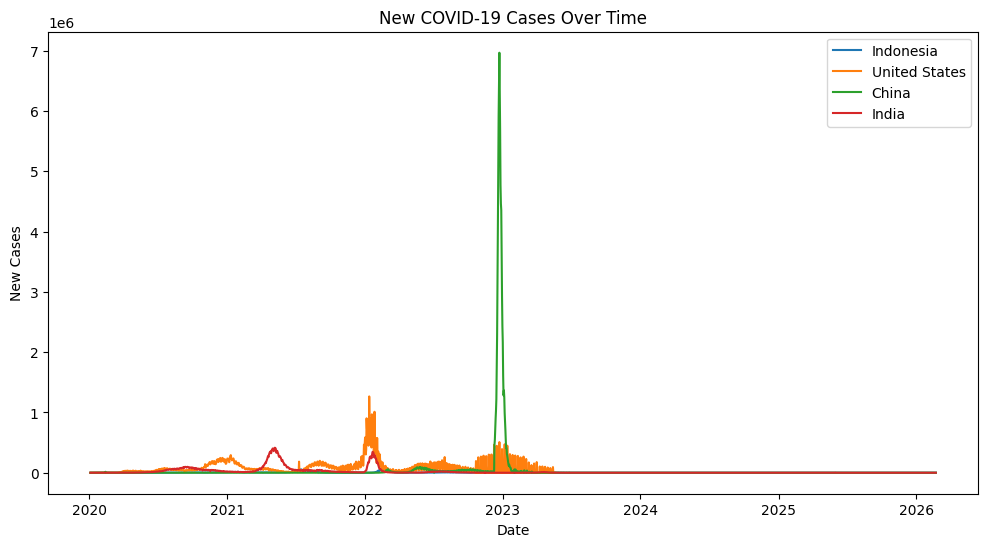

In [18]:
# Plot new cases over time for each country
plt.figure(figsize=(12, 6))

for country in countries:
    country_data = df[df["country"] == country]
    plt.plot(country_data["date"], country_data["new_cases"], label=country)

plt.legend()
plt.title("New COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

**Insight:**
- China (green line) recorded the most dramatic single spike in the dataset, with an extreme surge in early 2023 — coinciding with the abrupt end of its strict zero-COVID policy, which led to a rapid and massive wave of infections across the population.
- The United States (orange line) showed multiple smaller waves throughout the timeline but remained at a comparatively lower scale relative to China's 2023 peak.
- India (red line) experienced a notable surge around mid-2021, associated with the Delta variant wave, which was one of the most severe outbreaks in the country.
- Indonesia (blue line) also showed a mid-2021 peak consistent with the Delta wave, though at a smaller scale, followed by a gradual decline.

### Smoothed Trend (7-Day Average)

Daily data can be highly volatile. A 7-day rolling average is used to:
- Reduce noise
- Highlight underlying trends

In [19]:
# Calculate rolling average of new cases for smoother trends
df["rolling_cases"] = df.groupby("country")["new_cases"].transform(lambda x: x.rolling(window=7).mean())

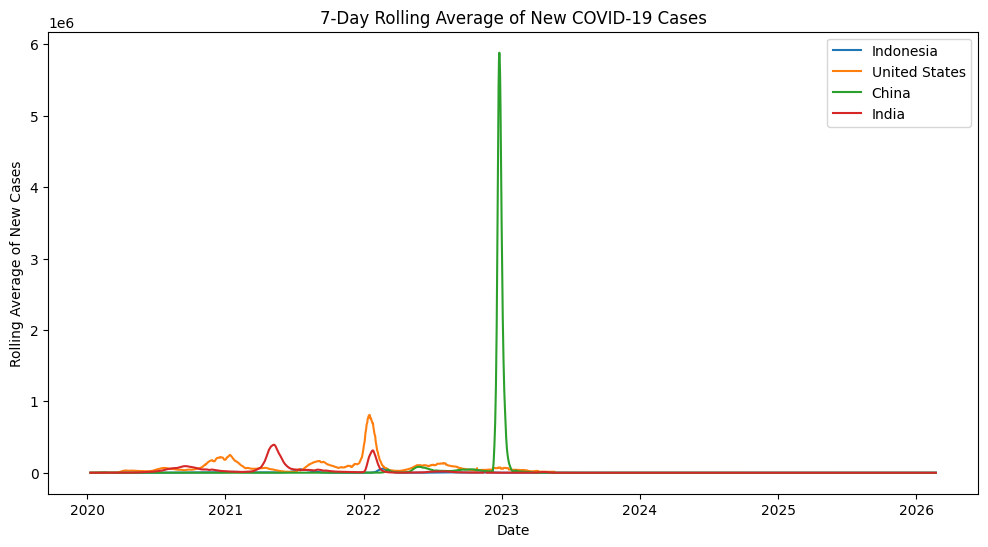

In [20]:
# Plot rolling average of new cases over time for each country
plt.figure(figsize=(12, 6))

for country in countries:
    data = df[df["country"] == country]
    plt.plot(data["date"], data["rolling_cases"], label=country)

plt.legend()
plt.title("7-Day Rolling Average of New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Rolling Average of New Cases")
plt.show()

**Insight:**
- The 7-day rolling average smooths out daily fluctuations and reveals clearer wave patterns for each country.
- The United States (orange line) shows the most pronounced multi-wave pattern, with repeated surges and declines across the observation period.
- India (red line) displays a sharp, distinct peak around mid-2021, confirming the severity of the Delta wave in the country even after noise reduction.
- Indonesia (blue line) follows a similar mid-2021 surge pattern, though at a smaller scale, with a relatively stable trend before and after the peak.
- China (green line) stays consistently flat and close to zero, which may reflect both effective containment and differences in reporting methodology.

### Death Rate Analysis

The death rate represents the proportion of deaths relative to total cases.

This metric is more informative than raw death counts because it:
- Accounts for case volume
- Reflects the severity of the outbreak

In [21]:
# Calculate death rate
df["death_rate"] = df["total_deaths"]/df["total_cases"]

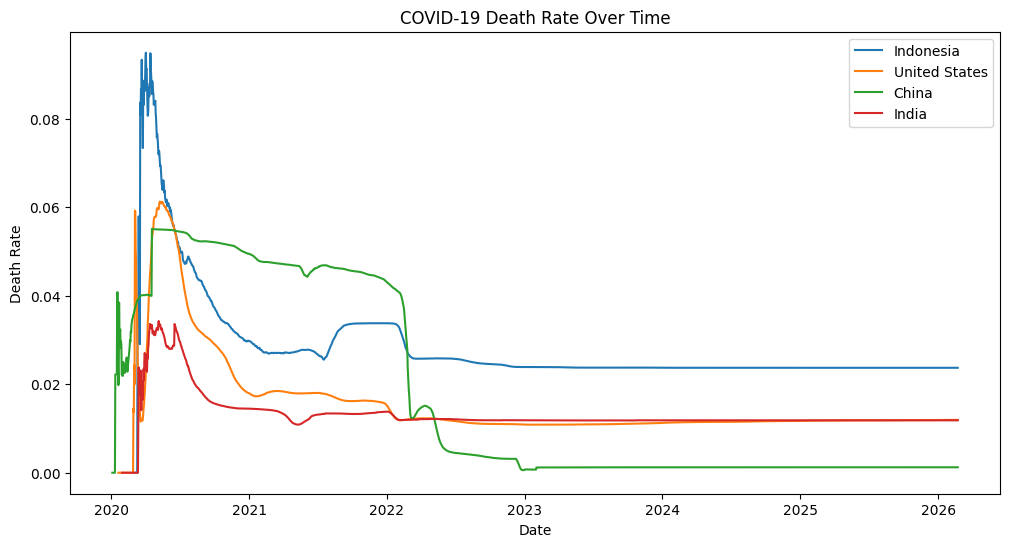

In [22]:
# Plot death rate over time for each country
plt.figure(figsize=(12, 6))

for country in countries:
    data = df[df["country"] == country]
    plt.plot(data["date"], data["death_rate"], label=country)

plt.legend()
plt.title("COVID-19 Death Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Death Rate")
plt.show()

**Insight:**
- Indonesia (blue line) recorded the highest death rate in the early phase of the pandemic, indicating a high proportion of deaths relative to confirmed cases — likely influenced by limited testing capacity, which caused many cases to go undetected.
- As the pandemic progressed, Indonesia's death rate gradually declined, reflecting improvements in healthcare response and increased testing.
- India (red line) showed a noticeable increase in death rate during the mid-2021 Delta wave, though it remained lower than Indonesia's early peak.
- The United States (orange line) maintained a relatively moderate and declining death rate over time, consistent with its large-scale testing and healthcare infrastructure.
- China (green line) consistently showed a very low death rate throughout the period, in line with its low reported case and death counts.

###  Vaccination Analysis

This section evaluates progress across countries.

Vaccination rate is calculated as:
number of vaccinated individuals / total population

This helps us understand:
- Each country's response to the pandemic
- The relationship between vaccination and case trends

In [23]:
# Calculate vaccination rate
df["vaccination_rate"] = df["people_vaccinated"]/df["population"]

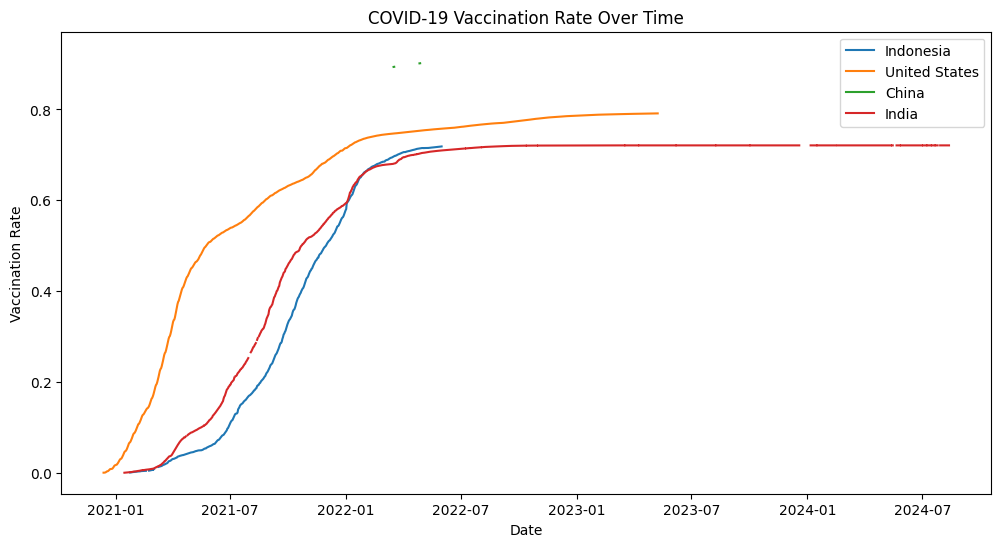

In [24]:
# Plot vaccination rate over time for each country
plt.figure(figsize=(12, 6))

for country in countries:
    data = df[df["country"] == country]
    plt.plot(data["date"], data["vaccination_rate"], label=country)

plt.legend()
plt.title("COVID-19 Vaccination Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Vaccination Rate")
plt.show()

**Insight:**
- China (green line) achieved the highest vaccination rate among the four countries by the end of the observation period, reflecting its large-scale domestic vaccine production and aggressive nationwide rollout program.
- India (red line) showed rapid vaccination growth from mid-2021 onward and reached a high coverage rate, a notable achievement given its massive population of over 1.4 billion.
- The United States (orange line) had the fastest early rollout, rising sharply in early 2021, but plateaued at a lower final rate compared to China and India.
- Indonesia (blue line) had the slowest initial rollout among the four but showed a steady upward trend, with acceleration in the second half of 2021 onwards.

## Country Comparison

In this section, we compare the latest COVID-19 conditions across countries based on:
- vaccination rates
- Overall pandemic response

This comparison highlights differences in strategies and outcomes.

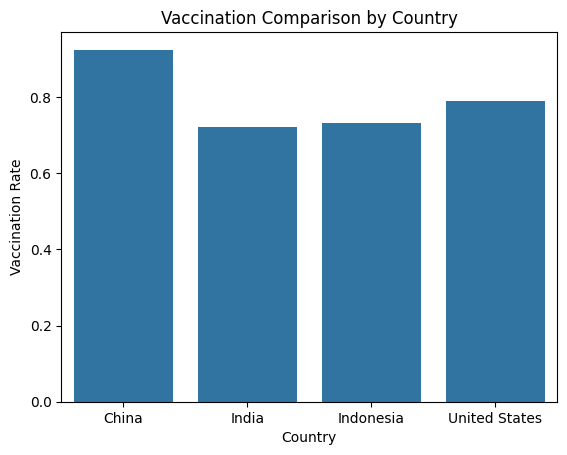

In [25]:
# Compare vaccination rates across countries at the latest date
latest = df.sort_values("date").groupby("country").tail(1)
latest = latest.dropna(subset=["vaccination_rate"])

# In case some countries have missing vaccination rates on the latest date, we can take the most recent non-null value for each country
latest = df.sort_values("date").groupby("country").apply(
    lambda x: x[x["vaccination_rate"].notna()].tail(1),
    include_groups=False
).reset_index(level=0).rename(columns={'level_0': 'country'})

sns.barplot(x="country", y="vaccination_rate", data=latest)
plt.title("Vaccination Comparison by Country")
plt.xlabel("Country")
plt.ylabel("Vaccination Rate")
plt.show()

**Insight:**
- China recorded the highest vaccination rate among the four countries, with coverage exceeding 0.9 (90% of the population vaccinated), reflecting the success of its large-scale domestic vaccination program.
- India and Indonesia followed with competitive vaccination rates, demonstrating significant progress despite their massive and geographically diverse populations.
- The United States recorded the lowest vaccination rate among the four in this snapshot, which may reflect vaccine hesitancy and plateau effects after the initial rapid rollout in 2021.
- Overall, all four countries achieved meaningful vaccination coverage, underscoring the global commitment to vaccination as a primary tool for managing the pandemic.

### Event Annotation

To improve interpretibility, key events are annotated directly on the timeline.

For example:
- Major COVID-19 waves (e.g., Delta variant)
- Policy changes or vaccination rollouts

Annotated visualizations make it easier to connect data patterns with real-world events.

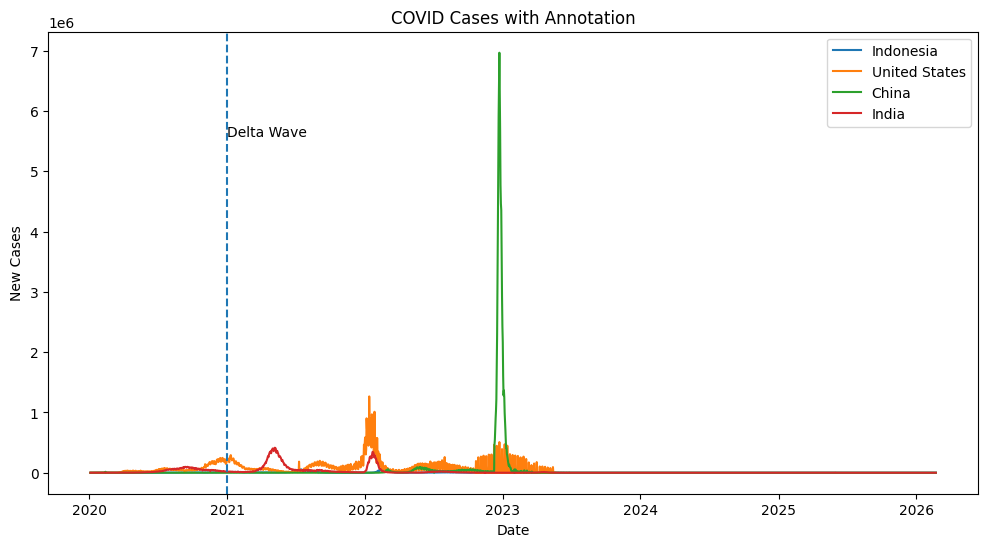

In [26]:
# Add annotation for significant events (e.g., Delta wave)
plt.figure(figsize=(12,6))

for country in countries:
    data = df[df["country"] == country]
    plt.plot(data["date"], data["new_cases"], label=country)

# Take max value for text position
y_max = df["new_cases"].max()

# Add vertical line and text annotation for Delta wave
plt.axvline(pd.to_datetime("2021-01-01"), linestyle='--')
plt.text(pd.to_datetime("2021-01-01"), y_max * 0.8, "Delta Wave")

plt.legend()
plt.title("COVID Cases with Annotation")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

**Insight:**
- The vertical dashed line is labeled "Delta Wave" and is placed at January 2021. However, it is worth noting that the Delta variant wave actually occurred around mid-2021 — the annotation position may serve as a general marker for the early-2021 surge period rather than the Delta wave specifically.
- China (green line) shows the most prominent spike in the chart, occurring around early 2023, which corresponds to the period immediately following China's abrupt end of its zero-COVID policy — resulting in a massive and rapid surge of infections across the country.
- India (red line) shows a visible but smaller surge around mid-2021, consistent with the actual Delta variant wave that severely impacted the country during that period.
- Indonesia (blue line) also shows a modest peak around the same mid-2021 period, aligned with the Delta wave's spread across Southeast Asia.
- The United States (orange line) remains relatively flat and close to the baseline throughout the annotated timeline, as its case counts are much smaller in scale compared to China's 2023 spike.

### Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables such as:
- Cases  
- Deaths  
- Vaccination rates  

This helps identify whether variables move together and can reveal hidden patterns in the data.

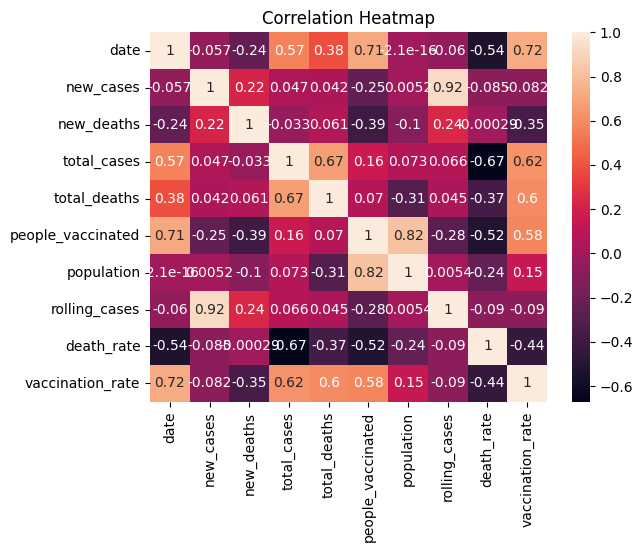

In [27]:
# Correlation heatmap
sns.heatmap(df.drop("country", axis=1).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Insight:**
- As expected, total cases and total deaths show a strong positive correlation, meaning countries with more cases also recorded more deaths overall.
- Vaccination rate shows a negative correlation with new cases over time, suggesting that higher vaccination coverage is associated with a reduction in daily case counts — indicating the effectiveness of vaccination campaigns.
- Variables such as new_cases and new_deaths are also positively correlated, which is consistent with the trajectory of the pandemic.

## Key Takeaways

- COVID-19 cases follow clear wave patterns across all countries.
- Larger countries tend to experience higher case peaks and longer transmission periods.
- Death trends generally lag behind case trends, reflecting the progression of the disease.
- Vaccination rollout plays a significant role in stabilizing and reducing case numbers.
- Significant differences exist between countries due to healthcare systems, policy responses, and population factors.

## Conclusion

This exploratory data analysis of COVID-19 across Indonesia, the United States, China, and India reveals several important patterns:

- The pandemic's impact varied widely across countries, with India and the United States bearing the highest case burdens, while China reported relatively low case counts throughout the observation period.
- Indonesia experienced a sharp surge in mid-2021 consistent with the global Delta variant wave, underscoring how new variants can rapidly change case trajectories even in countries with previously lower transmission.
- Vaccination rates show a meaningful negative correlation with new case growth, providing data-driven evidence of the vaccines' impact on reducing transmission.
- Death rates evolved over time across all countries, with early periods generally showing higher rates that gradually declined as healthcare systems adapted and vaccination coverage increased.

Further analysis incorporating government policy stringency, mobility data, or variant-level breakdowns could provide even deeper insights into the factors driving these differences.